# Multimodal Cross-Attention Fusion — Robustness (10 Seeds)

## Objective
Run the **multimodal robustness** protocol from `Multi_modal_Robustness_Experiments_30_seeds.ipynb` on **FashionStyle14** using **bidirectional cross-attention fusion** between frozen **CLIP ViT-B/32** image features and frozen **BERT-base-uncased** text features.

For each of **30** stratified train/validation/test splits (seeds in `seeds_list.txt`), we train only the fusion and classifier heads while backbones stay frozen. Model initialization uses a fixed seed (**42**); split randomness comes from each data seed.

## Architecture (`CrossAttentionFusion`)
Frozen **CLIP** yields one global image vector; frozen **BERT** yields a **full caption token sequence** (not `[CLS]` only).

1. Project image to one token and each text token to shared `hidden_dim` (512).
2. **Image-to-text** cross-attention: the image token **queries** all caption tokens (keys/values), with padding mask.
3. **Text-to-image** cross-attention: each caption token **queries** the image token (keys/values).
4. Residual + layer norm on both branches; **masked mean-pool** over attended text tokens.
5. Concatenate attended image vector + pooled text vector, MLP fusion, then classifier (14 classes).

## Pipeline
1. Resolve paths, load **30 seeds**, set hyperparameters.
2. Check GPU/CPU, VRAM, adaptive batch size, AMP on CUDA.
3. Load images from `complete_dataset.csv`, merge captions, keep on-disk rows with non-empty text.
4. For **each seed** (section 6): stratified 70% / 15% / 15% split, train with early stopping on **validation macro-F1**, evaluate on test, save artifacts.
5. **Evaluation** (section 8): aggregate overall and per-class metrics (mean +/- std, 95% CI) from saved results.

## Inputs
| Input | Description |
|-------|-------------|
| `FashionStyle14_v1/complete_dataset.csv` | Relative image paths (`dataset/<style>/...`). |
| `FashionStyle14_v1/seeds_list.txt` | **30** robustness seeds (`Seed N` lines). |
| `FashionStyle14_v1/caption/fashion_captions_llava_success.csv` | Captions (adjust `CAPTION_CSV` in section 1 if needed). |
| `FashionStyle14_v1/dataset/` | Image files on disk. |
| Pre-trained weights | Hugging Face: `openai/clip-vit-base-patch32`, `bert-base-uncased`. |

## Outputs
**`results/multimodal/cross_attention/`**

| Per seed (`seed_<seed>/`) | Aggregated |
|---------------------------|------------|
| `best_model.pt` | `all_seeds_summary.csv` |
| `training_history.json` | `aggregation_summary.csv` |
| `test_metrics.json` | `per_class_metrics_summary.csv` |
| `per_class.csv` | |
| `classification_report.json` | |

Learning curves are shown in-notebook only (`plt.show()`; not saved as PNG).

## Notes
- Code and section titles are **English** only.
- Open the notebook from the repo root or `FusionStyle/` so path resolution succeeds.


## 1. Configuration, imports, and paths


In [ ]:
from __future__ import annotations

import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from scipy import stats
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, CLIPModel, CLIPProcessor

warnings.filterwarnings("ignore", category=UserWarning)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Hyperparameters (aligned with fusion robustness reference notebooks)
LEARNING_RATE = 5e-5
BATCH_SIZE = 32
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
MODEL_INIT_SEED = 42
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
MAX_SEQ_LENGTH = 128

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
BERT_MODEL_ID = "bert-base-uncased"
MODEL_KEY = "cross_attention"

random.seed(MODEL_INIT_SEED)
np.random.seed(MODEL_INIT_SEED)
torch.manual_seed(MODEL_INIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def load_seeds(seeds_file: Path) -> List[int]:
    """Load all 30 robustness seeds from seeds_list.txt."""
    if not seeds_file.is_file():
        raise FileNotFoundError(f"Missing seeds file: {seeds_file}")
    content = seeds_file.read_text(encoding="utf-8")
    matches = re.findall(r"Seed\s+(\d+)", content, flags=re.IGNORECASE)
    seeds = sorted({int(s) for s in matches if 1 <= int(s) <= 500})
    if len(seeds) != 30:
        print(f"Warning: expected 30 seeds in file, found {len(seeds)}")
    return seeds[:10]


def resolve_paths() -> Tuple[Path, Path, Path, Path]:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "FusionStyle",
        cwd.parent / "FusionStyle",
        cwd / "StyleFusion",
        cwd.parent / "StyleFusion",
    ]
    for root in candidates:
        data_dir = root / "FashionStyle14_v1"
        dataset_dir = data_dir / "dataset"
        if (data_dir / "complete_dataset.csv").is_file() and dataset_dir.is_dir():
            results_root = root / "results" / "multimodal" / MODEL_KEY
            caption_csv = data_dir / "caption" / "fashion_captions_llava_success.csv"
            return root, data_dir, results_root, caption_csv
    raise FileNotFoundError(
        "Could not locate FashionStyle14_v1 with complete_dataset.csv and dataset/. "
        "Open the notebook from the repo root or FusionStyle/."
    )


PROJECT_ROOT, DATA_DIR, RESULTS_ROOT, CAPTION_CSV = resolve_paths()
IMAGE_ROOT = DATA_DIR
SEEDS_FILE = DATA_DIR / "seeds_list.txt"
COMPLETE_CSV = DATA_DIR / "complete_dataset.csv"
SEEDS = load_seeds(SEEDS_FILE)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CAPTION_CSV:", CAPTION_CSV)
print("RESULTS_ROOT:", RESULTS_ROOT)
print(f"Loaded {len(SEEDS)} seeds:", SEEDS)

PROJECT_ROOT: /home/sandy/Document/FusionStyle
DATA_DIR: /home/sandy/Document/FusionStyle/FashionStyle14_v1
CAPTION_CSV: /home/sandy/Document/FusionStyle/FashionStyle14_v1/caption/fashion_captions_llava_success.csv
RESULTS_ROOT: /home/sandy/Document/FusionStyle/results/multimodal/cross_attention
Loaded 10 seeds: [13, 14, 16, 17, 45, 48, 53, 58, 72, 102]


## 2. Hardware check and runtime settings


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    total_mem_gb = props.total_memory / (1024**3)
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {total_mem_gb:.2f} GB")
    if total_mem_gb < 8:
        BATCH_SIZE = 4
    elif total_mem_gb < 12:
        BATCH_SIZE = 8
    else:
        BATCH_SIZE = 16
else:
    print("CUDA not available; using CPU (training will be slow).")
    BATCH_SIZE = 4

NUM_WORKERS = 0
print(f"Selected BATCH_SIZE: {BATCH_SIZE}")
print(f"Using AMP on CUDA: {use_amp}")


CUDA device: NVIDIA GeForce RTX 4060
Total GPU memory: 7.60 GB
Selected BATCH_SIZE: 4
Using AMP on CUDA: True


## 3. Load dataset, captions, and stratified split helper


In [19]:
def normalize_rel_path(path_str: str) -> str:
    return str(path_str).strip().replace("\\", "/")


def canonical_merge_key(raw: str) -> str:
    s = normalize_rel_path(raw).lstrip("./")
    low = s.lower()
    for pref in ("fashionstyle14_v1/",):
        if low.startswith(pref):
            s = s[len(pref) :].lstrip("/")
            low = s.lower()
    marker = "dataset/"
    ix = low.find(marker)
    if ix >= 0:
        return normalize_rel_path(s[ix:])
    p = Path(s)
    if p.is_absolute():
        try:
            rel = Path(p.resolve()).relative_to(IMAGE_ROOT.resolve())
            return normalize_rel_path(str(rel).replace(os.sep, "/"))
        except ValueError:
            pass
    return s


def load_complete_dataset(csv_path: Path) -> pd.DataFrame:
    lines = csv_path.read_text(encoding="utf-8").splitlines()
    rel = [ln.strip() for ln in lines if ln.strip()]
    df = pd.DataFrame({"rel_path": rel})
    df["rel_path"] = df["rel_path"].map(normalize_rel_path)
    df["merge_key"] = df["rel_path"].map(canonical_merge_key)
    df["style"] = df["merge_key"].str.split("/").str[1]
    df["abs_path"] = df["rel_path"].apply(lambda r: str((IMAGE_ROOT / r.replace("/", os.sep)).resolve()))
    df = df[df["abs_path"].map(os.path.isfile)].reset_index(drop=True)
    return df


def load_captions_long(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8")
    work = df.copy()
    if "status" in work.columns:
        work = work[work["status"].astype(str).str.lower() == "success"]
    path_col = None
    for c in work.columns:
        if c.lower().strip() in {"image_path", "rel_path", "path", "filename", "file_path", "filepath", "image"}:
            path_col = c
            break
    if path_col is None:
        raise ValueError(f"Caption CSV needs an image path column; got {list(work.columns)}")
    cap_col = None
    for c in work.columns:
        if c.lower().strip() in {"caption", "text", "description"}:
            cap_col = c
            break
    if cap_col is None:
        named = [c for c in work.columns if "caption" in str(c).lower()]
        cap_col = named[0] if named else None
    if cap_col is None:
        raise ValueError(f"Caption CSV needs a caption column; got {list(work.columns)}")
    out = work[[path_col, cap_col]].rename(columns={path_col: "raw_image_path", cap_col: "caption"})
    out["merge_key"] = out["raw_image_path"].map(canonical_merge_key)
    out["caption"] = out["caption"].fillna("").astype(str).str.strip()
    out = out[out["caption"] != ""].drop_duplicates(subset=["merge_key"], keep="last")
    return out[["merge_key", "caption"]].reset_index(drop=True)


df_paths = load_complete_dataset(COMPLETE_CSV)
cap_df = load_captions_long(CAPTION_CSV)
df_full = df_paths.merge(cap_df[["merge_key", "caption"]], on="merge_key", how="inner").reset_index(drop=True)

if len(df_full) == 0:
    raise ValueError("No rows after joining images and captions.")

classes = sorted(df_full["style"].unique().tolist())
assert len(classes) == 14, f"Expected 14 classes, got {len(classes)}: {classes}"
style_to_idx = {s: i for i, s in enumerate(classes)}
num_classes = len(classes)
idx_to_style = {i: s for s, i in style_to_idx.items()}

print("Samples with captions (files on disk):", len(df_full))
print("Number of classes:", num_classes)
print("Classes:", classes)
print(f"Planned experiments: {len(SEEDS)} seeds x 1 model = {len(SEEDS)} runs")


def split_by_seed(df: pd.DataFrame, seed_value: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df,
        test_size=(VAL_RATIO + TEST_RATIO),
        stratify=df["style"],
        random_state=seed_value,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=temp_df["style"],
        random_state=seed_value,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


Samples with captions (files on disk): 13212
Number of classes: 14
Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Planned experiments: 10 seeds x 1 model = 10 runs


## 4. Cross-attention fusion model, dataset, and collate


In [20]:
class FashionMultiModalFrameDataset(Dataset):
    """Image path + caption + label (CLIP processor applied in collate)."""

    def __init__(self, frame: pd.DataFrame, style_to_idx: Dict[str, int]):
        self.frame = frame.reset_index(drop=True)
        self.style_to_idx = style_to_idx

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.frame.iloc[idx]
        return {
            "abs_path": row["abs_path"],
            "rel_path": row["rel_path"],
            "caption": str(row["caption"]),
            "label": self.style_to_idx[row["style"]],
            "style": row["style"],
        }


class CrossAttentionFusion(nn.Module):
    """Bidirectional cross-attention: one image token <-> caption token sequence (length T)."""

    def __init__(
        self,
        visual_dim: int = 512,
        text_dim: int = 768,
        hidden_dim: int = 512,
        num_heads: int = 8,
        num_classes: int = 14,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.visual_proj = nn.Linear(visual_dim, hidden_dim)
        self.text_proj = nn.Linear(text_dim, hidden_dim)

        self.img_to_txt_attn = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
        self.txt_to_img_attn = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)

        self.norm_img = nn.LayerNorm(hidden_dim)
        self.norm_txt = nn.LayerNorm(hidden_dim)

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def _masked_mean_pool(self, tokens: torch.Tensor, key_padding_mask: Optional[torch.Tensor]) -> torch.Tensor:
        """Mean-pool sequence tokens; ignore padded positions when mask is provided."""
        if key_padding_mask is None:
            return tokens.mean(dim=1)
        valid = (~key_padding_mask).unsqueeze(-1).float()
        return (tokens * valid).sum(dim=1) / valid.sum(dim=1).clamp(min=1.0)

    def forward(
        self,
        visual_features: torch.Tensor,
        text_tokens: torch.Tensor,
        key_padding_mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # visual_features: (B, visual_dim); text_tokens: (B, T, text_dim)
        # key_padding_mask: (B, T), True on padded positions (MultiheadAttention convention)
        v = self.visual_proj(visual_features).unsqueeze(1)
        t = self.text_proj(text_tokens)

        v_attended, v_attn_weights = self.img_to_txt_attn(
            query=v,
            key=t,
            value=t,
            key_padding_mask=key_padding_mask,
            need_weights=True,
        )
        t_attended, t_attn_weights = self.txt_to_img_attn(
            query=t,
            key=v,
            value=v,
            need_weights=True,
        )

        v_out = self.norm_img(v + v_attended).squeeze(1)
        t_out = self.norm_txt(t + t_attended)
        t_pooled = self._masked_mean_pool(t_out, key_padding_mask)

        fused = self.fusion(torch.cat([v_out, t_pooled], dim=-1))
        logits = self.classifier(fused)
        return logits, v_attn_weights, t_attn_weights


class ClipBertCrossAttentionClassifier(nn.Module):
    """Frozen CLIP + frozen BERT with trainable CrossAttentionFusion head."""

    def __init__(
        self,
        clip_model: CLIPModel,
        clip_processor: CLIPProcessor,
        bert_model: AutoModel,
        bert_tokenizer: AutoTokenizer,
        num_classes: int,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.clip_model = clip_model
        self.clip_processor = clip_processor
        self.bert_model = bert_model
        self.bert_tokenizer = bert_tokenizer
        for p in self.clip_model.parameters():
            p.requires_grad = False
        for p in self.bert_model.parameters():
            p.requires_grad = False
        self.clip_model.eval()
        self.bert_model.eval()

        visual_dim = int(clip_model.config.projection_dim)
        textual_dim = int(bert_model.config.hidden_size)
        self.fusion = CrossAttentionFusion(
            visual_dim=visual_dim,
            text_dim=textual_dim,
            hidden_dim=512,
            num_heads=8,
            num_classes=num_classes,
            dropout=dropout,
        )

    def forward(self, pixel_values: torch.Tensor, captions: List[str]) -> torch.Tensor:
        dev = pixel_values.device
        with torch.no_grad():
            visual = self.clip_model.get_image_features(pixel_values=pixel_values).float()
            enc = self.bert_tokenizer(
                captions,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
            ).to(dev)
            text_tokens = self.bert_model(**enc).last_hidden_state.float()
        pad_mask = enc["attention_mask"] == 0
        logits, _, _ = self.fusion(visual, text_tokens, key_padding_mask=pad_mask)
        return logits


_BACKBONE_CACHE: Dict[str, Any] = {}


def get_clip_bert():
    if "clip_model" not in _BACKBONE_CACHE:
        _BACKBONE_CACHE["clip_model"] = CLIPModel.from_pretrained(CLIP_MODEL_ID)
        _BACKBONE_CACHE["clip_processor"] = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
        _BACKBONE_CACHE["bert_model"] = AutoModel.from_pretrained(BERT_MODEL_ID)
        _BACKBONE_CACHE["bert_tokenizer"] = AutoTokenizer.from_pretrained(BERT_MODEL_ID)
    return (
        _BACKBONE_CACHE["clip_model"],
        _BACKBONE_CACHE["clip_processor"],
        _BACKBONE_CACHE["bert_model"],
        _BACKBONE_CACHE["bert_tokenizer"],
    )


def build_model() -> ClipBertCrossAttentionClassifier:
    clip_m, clip_p, bert_m, bert_t = get_clip_bert()
    return ClipBertCrossAttentionClassifier(clip_m, clip_p, bert_m, bert_t, num_classes)


def collate_clip_bert(batch: List[Dict[str, Any]], clip_processor: CLIPProcessor) -> Dict[str, Any]:
    images = [Image.open(item["abs_path"]).convert("RGB") for item in batch]
    pixel_values = clip_processor(images=images, return_tensors="pt")["pixel_values"]
    return {
        "pixel_values": pixel_values,
        "captions": [item["caption"] for item in batch],
        "labels": torch.tensor([item["label"] for item in batch], dtype=torch.long),
    }


_, clip_processor, _, _ = get_clip_bert()


def collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    return collate_clip_bert(batch, clip_processor)


print("Cross-attention model, dataset, and collate ready.")

/home/sandy/miniconda3/envs/fusionstyle/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Cross-attention model, dataset, and collate ready.


## 5. Training, evaluation, and aggregation utilities


In [21]:
def set_model_init_seed() -> None:
    random.seed(MODEL_INIT_SEED)
    np.random.seed(MODEL_INIT_SEED)
    torch.manual_seed(MODEL_INIT_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def forward_batch(model: nn.Module, batch: Dict[str, Any]) -> torch.Tensor:
    return model(batch["pixel_values"], batch["captions"])


def evaluate_model(
    model: nn.Module, loader: DataLoader, criterion: nn.Module
) -> Tuple[float, Dict[str, float], np.ndarray, np.ndarray]:
    model.eval()
    total_loss = 0.0
    all_preds: List[int] = []
    all_labels: List[int] = []
    n = len(loader.dataset)
    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].to(device, non_blocking=True)
            batch_gpu = {
                k: (v.to(device, non_blocking=True) if torch.is_tensor(v) else v)
                for k, v in batch.items()
            }
            with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
                logits = forward_batch(model, batch_gpu)
                loss = criterion(logits, labels)
            total_loss += float(loss.item()) * labels.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    avg_loss = total_loss / max(n, 1)
    metrics = {
        "accuracy": float(accuracy_score(all_labels, all_preds)),
        "macro_precision": float(precision_score(all_labels, all_preds, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(all_labels, all_preds, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(all_labels, all_preds, average="macro", zero_division=0)),
        "loss": float(avg_loss),
    }
    return avg_loss, metrics, np.array(all_preds), np.array(all_labels)


def train_one_epoch(
    model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module
) -> Tuple[float, float]:
    model.train()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp and device.type == "cuda")
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in loader:
        labels = batch["labels"].to(device, non_blocking=True)
        batch_gpu = {
            k: (v.to(device, non_blocking=True) if torch.is_tensor(v) else v)
            for k, v in batch.items()
        }
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
            logits = forward_batch(model, batch_gpu)
            loss = criterion(logits, labels)
        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        total_loss += float(loss.item()) * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += int((preds == labels).sum().item())
        total += int(labels.size(0))
    return total_loss / max(total, 1), correct / max(total, 1)


def plot_learning_curves(history: Dict[str, Any], title: str) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(epochs, history["val_macro_f1"], label="val macro F1")
    axes[1].plot(epochs, history["train_acc"], label="train acc", alpha=0.7)
    axes[1].plot(epochs, history["val_acc"], label="val acc", alpha=0.7)
    axes[1].set_title("Metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def per_class_dataframe(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    pc_p = precision_score(y_true, y_pred, average=None, zero_division=0)
    pc_r = recall_score(y_true, y_pred, average=None, zero_division=0)
    pc_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    rows = []
    for i, cls in enumerate(classes):
        rows.append({
            "class": cls,
            "acc": float(pc_r[i]),
            "precision": float(pc_p[i]),
            "recall": float(pc_r[i]),
            "f1": float(pc_f1[i]),
        })
    return pd.DataFrame(rows)


def calculate_stats(values: List[float], name: str) -> Dict[str, float]:
    arr = np.asarray(values, dtype=float)
    mean_val = float(np.mean(arr))
    std_val = float(np.std(arr))
    if len(arr) > 1:
        ci_lower, ci_upper = stats.t.interval(0.95, len(arr) - 1, loc=mean_val, scale=stats.sem(arr))
    else:
        ci_lower = ci_upper = mean_val
    return {
        "metric": name,
        "mean": mean_val,
        "std": std_val,
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "median": float(np.median(arr)),
        "ci_95_lower": float(ci_lower),
        "ci_95_upper": float(ci_upper),
        "n": int(len(arr)),
    }


def make_loaders(train_df, val_df, test_df) -> Tuple[DataLoader, DataLoader, DataLoader]:
    train_ds = FashionMultiModalFrameDataset(train_df, style_to_idx)
    val_ds = FashionMultiModalFrameDataset(val_df, style_to_idx)
    test_ds = FashionMultiModalFrameDataset(test_df, style_to_idx)
    kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    return (
        DataLoader(train_ds, shuffle=True, **kw),
        DataLoader(val_ds, shuffle=False, **kw),
        DataLoader(test_ds, shuffle=False, **kw),
    )


def train_cross_attention_seed(
    seed_value: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    train_df: pd.DataFrame,
    out_dir: Path,
) -> Dict[str, Any]:
    out_dir.mkdir(parents=True, exist_ok=True)
    set_model_init_seed()
    model = build_model().to(device)

    y_train = train_df["style"].map(style_to_idx).values
    class_weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32, device=device)
    )
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "train_acc": [], "val_acc": []}
    best_f1 = -1.0
    best_state = None
    patience_left = EARLY_STOPPING_PATIENCE

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_metrics, _, _ = evaluate_model(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_metrics["accuracy"])
        print(
            f"  Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_metrics['accuracy']:.4f} macroF1 {val_metrics['macro_f1']:.4f}"
        )
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            patience_left = EARLY_STOPPING_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("  Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save(model.state_dict(), out_dir / "best_model.pt")
    with open(out_dir / "training_history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

    _, test_metrics, test_preds, test_labels = evaluate_model(model, test_loader, criterion)
    target_names = [idx_to_style[i] for i in range(num_classes)]
    report = classification_report(
        test_labels,
        test_preds,
        labels=list(range(num_classes)),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
    per_class_df = per_class_dataframe(test_labels, test_preds)

    with open(out_dir / "test_metrics.json", "w", encoding="utf-8") as f:
        json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)
    with open(out_dir / "classification_report.json", "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)
    per_class_df.to_csv(out_dir / "per_class.csv", index=False, encoding="utf-8")

    print(f"  Test metrics: {test_metrics}")
    plot_learning_curves(history, title=f"{MODEL_KEY} (seed {seed_value})")

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return {"seed": seed_value, "test_metrics": test_metrics, "report": report}


def aggregate_cross_attention_results() -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load per-seed artifacts and build overall + per-class aggregation tables."""
    metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]
    summary_path = RESULTS_ROOT / "all_seeds_summary.csv"
    if not summary_path.is_file():
        print(f"[{MODEL_KEY}] Missing {summary_path}; run section 6 first.")
        return pd.DataFrame(), pd.DataFrame()

    df_seeds = pd.read_csv(summary_path)
    agg_rows = []
    for col in metric_cols:
        if col not in df_seeds.columns:
            continue
        s = calculate_stats(df_seeds[col].tolist(), col)
        s["model"] = MODEL_KEY
        agg_rows.append(s)
    agg_df = pd.DataFrame(agg_rows)
    agg_df.to_csv(RESULTS_ROOT / "aggregation_summary.csv", index=False, encoding="utf-8")

    per_class_rows = []
    style_names = None
    for seed_value in SEEDS:
        report_path = RESULTS_ROOT / f"seed_{seed_value}" / "classification_report.json"
        if not report_path.is_file():
            continue
        with open(report_path, encoding="utf-8") as f:
            report = json.load(f)
        if style_names is None:
            style_names = sorted(
                [k for k in report.keys() if k not in {"accuracy", "macro avg", "weighted avg"}]
            )
        for style in style_names:
            if style not in report:
                continue
            per_class_rows.append({
                "seed": seed_value,
                "style": style,
                "f1": report[style]["f1-score"],
                "precision": report[style]["precision"],
                "recall": report[style]["recall"],
            })

    if not per_class_rows:
        return agg_df, pd.DataFrame()

    pc_long = pd.DataFrame(per_class_rows)
    summary_pc = []
    for style, grp in pc_long.groupby("style"):
        f1_stats = calculate_stats(grp["f1"].tolist(), f"{style} F1")
        summary_pc.append({
            "model": MODEL_KEY,
            "Style": style,
            "F1_Mean": f1_stats["mean"],
            "F1_Std": f1_stats["std"],
            "F1_CV%": (f1_stats["std"] / f1_stats["mean"] * 100.0) if f1_stats["mean"] else 0.0,
            "Precision_Mean": float(grp["precision"].mean()),
            "Recall_Mean": float(grp["recall"].mean()),
        })
    pc_df = pd.DataFrame(summary_pc).sort_values("Style").reset_index(drop=True)
    pc_df.to_csv(RESULTS_ROOT / "per_class_metrics_summary.csv", index=False, encoding="utf-8")
    return agg_df, pc_df


print("Training and aggregation utilities ready.")


Training and aggregation utilities ready.


## 6. Run cross-attention robustness (10 seeds)


[cross_attention] Experiment 1/10 | split seed = 13
  Split sizes: train=9248, val=1982, test=1982


  Epoch 01 | train loss 1.9404 acc 0.3469 | val loss 0.9684 acc 0.6831 macroF1 0.6669
  Epoch 02 | train loss 1.0414 acc 0.6405 | val loss 0.6518 acc 0.7760 macroF1 0.7747
  Epoch 03 | train loss 0.8076 acc 0.7284 | val loss 0.5590 acc 0.8098 macroF1 0.8100
  Epoch 04 | train loss 0.7074 acc 0.7728 | val loss 0.5406 acc 0.8138 macroF1 0.8132
  Epoch 05 | train loss 0.6160 acc 0.7966 | val loss 0.5390 acc 0.8148 macroF1 0.8129
  Epoch 06 | train loss 0.5832 acc 0.8114 | val loss 0.5584 acc 0.8174 macroF1 0.8156
  Epoch 07 | train loss 0.5349 acc 0.8256 | val loss 0.5253 acc 0.8264 macroF1 0.8253
  Epoch 08 | train loss 0.4919 acc 0.8380 | val loss 0.5590 acc 0.8254 macroF1 0.8250
  Epoch 09 | train loss 0.4815 acc 0.8487 | val loss 0.5226 acc 0.8350 macroF1 0.8339
  Epoch 10 | train loss 0.4542 acc 0.8561 | val loss 0.5186 acc 0.8385 macroF1 0.8378
  Epoch 11 | train loss 0.4324 acc 0.8596 | val loss 0.5692 acc 0.8204 macroF1 0.8162
  Epoch 12 | train loss 0.4230 acc 0.8628 | val loss 0

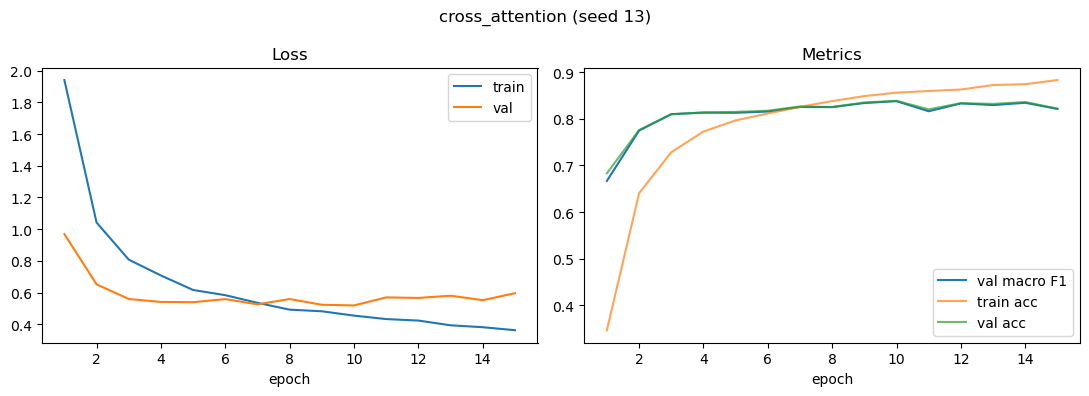

[cross_attention] Experiment 2/10 | split seed = 14
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 1.9510 acc 0.3397 | val loss 0.9896 acc 0.6821 macroF1 0.6728
  Epoch 02 | train loss 1.0420 acc 0.6412 | val loss 0.7057 acc 0.7538 macroF1 0.7517
  Epoch 03 | train loss 0.8046 acc 0.7300 | val loss 0.6303 acc 0.7740 macroF1 0.7720
  Epoch 04 | train loss 0.7006 acc 0.7709 | val loss 0.6004 acc 0.7952 macroF1 0.7950
  Epoch 05 | train loss 0.6106 acc 0.7969 | val loss 0.5576 acc 0.8073 macroF1 0.8092
  Epoch 06 | train loss 0.5619 acc 0.8184 | val loss 0.5593 acc 0.8108 macroF1 0.8108
  Epoch 07 | train loss 0.5328 acc 0.8292 | val loss 0.5580 acc 0.8158 macroF1 0.8160
  Epoch 08 | train loss 0.4997 acc 0.8378 | val loss 0.5352 acc 0.8290 macroF1 0.8294
  Epoch 09 | train loss 0.4815 acc 0.8449 | val loss 0.5267 acc 0.8224 macroF1 0.8238
  Epoch 10 | train loss 0.4564 acc 0.8581 | val loss 0.5467 acc 0.8199 macroF1 0.8197
  Epoch 11 | train loss 0.4323 acc 0.8633

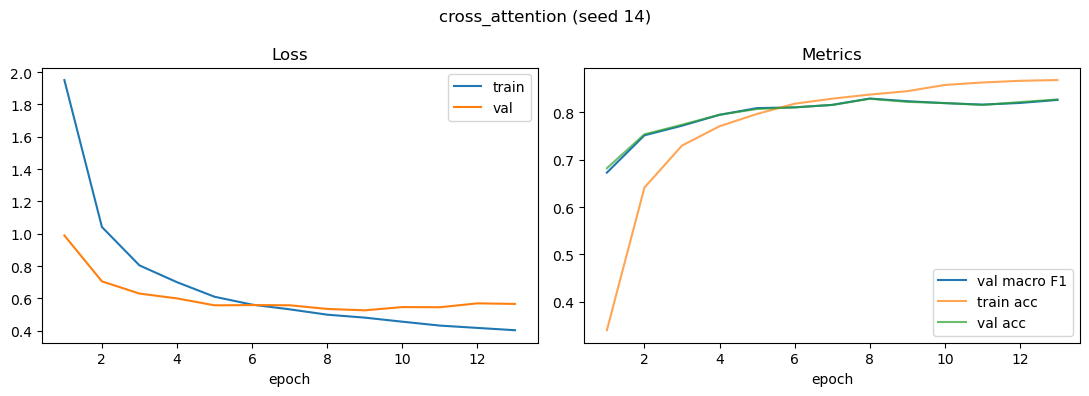

[cross_attention] Experiment 3/10 | split seed = 16
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 1.9323 acc 0.3476 | val loss 0.9075 acc 0.7053 macroF1 0.6900
  Epoch 02 | train loss 1.0461 acc 0.6389 | val loss 0.6765 acc 0.7608 macroF1 0.7559
  Epoch 03 | train loss 0.8266 acc 0.7169 | val loss 0.6050 acc 0.7931 macroF1 0.7914
  Epoch 04 | train loss 0.7149 acc 0.7601 | val loss 0.5765 acc 0.8052 macroF1 0.8061
  Epoch 05 | train loss 0.6492 acc 0.7871 | val loss 0.5156 acc 0.8280 macroF1 0.8271
  Epoch 06 | train loss 0.5810 acc 0.8122 | val loss 0.5253 acc 0.8300 macroF1 0.8296
  Epoch 07 | train loss 0.5410 acc 0.8244 | val loss 0.5515 acc 0.8219 macroF1 0.8192
  Epoch 08 | train loss 0.5215 acc 0.8352 | val loss 0.5506 acc 0.8285 macroF1 0.8278
  Epoch 09 | train loss 0.4995 acc 0.8402 | val loss 0.5530 acc 0.8229 macroF1 0.8208
  Epoch 10 | train loss 0.4634 acc 0.8519 | val loss 0.6001 acc 0.8204 macroF1 0.8190
  Epoch 11 | train loss 0.4509 acc 0.8524

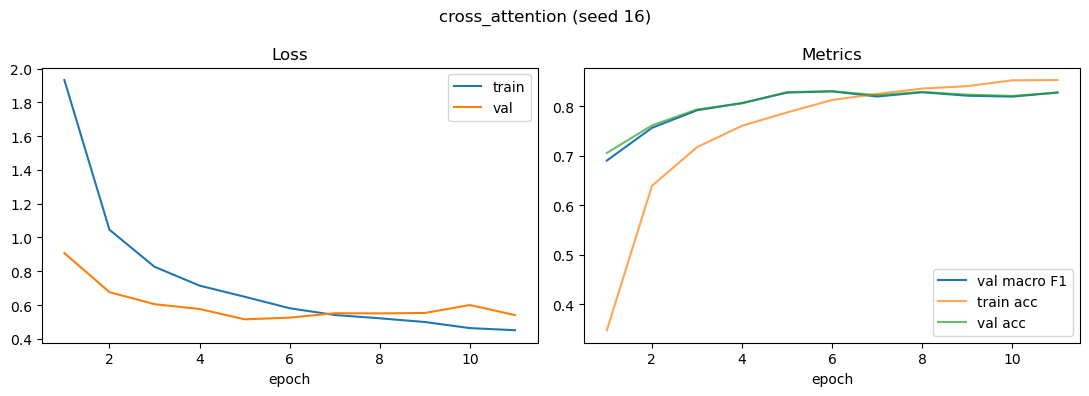

[cross_attention] Experiment 4/10 | split seed = 17
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 1.9158 acc 0.3530 | val loss 0.9680 acc 0.6670 macroF1 0.6588
  Epoch 02 | train loss 1.0202 acc 0.6478 | val loss 0.6470 acc 0.7810 macroF1 0.7817
  Epoch 03 | train loss 0.8039 acc 0.7271 | val loss 0.5654 acc 0.8108 macroF1 0.8130
  Epoch 04 | train loss 0.6965 acc 0.7644 | val loss 0.5449 acc 0.8052 macroF1 0.8070
  Epoch 05 | train loss 0.6336 acc 0.7950 | val loss 0.5491 acc 0.8158 macroF1 0.8161
  Epoch 06 | train loss 0.5872 acc 0.8103 | val loss 0.5406 acc 0.8163 macroF1 0.8161
  Epoch 07 | train loss 0.5383 acc 0.8262 | val loss 0.5479 acc 0.8174 macroF1 0.8178
  Epoch 08 | train loss 0.5243 acc 0.8303 | val loss 0.5475 acc 0.8174 macroF1 0.8152
  Epoch 09 | train loss 0.4921 acc 0.8444 | val loss 0.5387 acc 0.8254 macroF1 0.8247
  Epoch 10 | train loss 0.4623 acc 0.8518 | val loss 0.5315 acc 0.8285 macroF1 0.8292
  Epoch 11 | train loss 0.4341 acc 0.8604

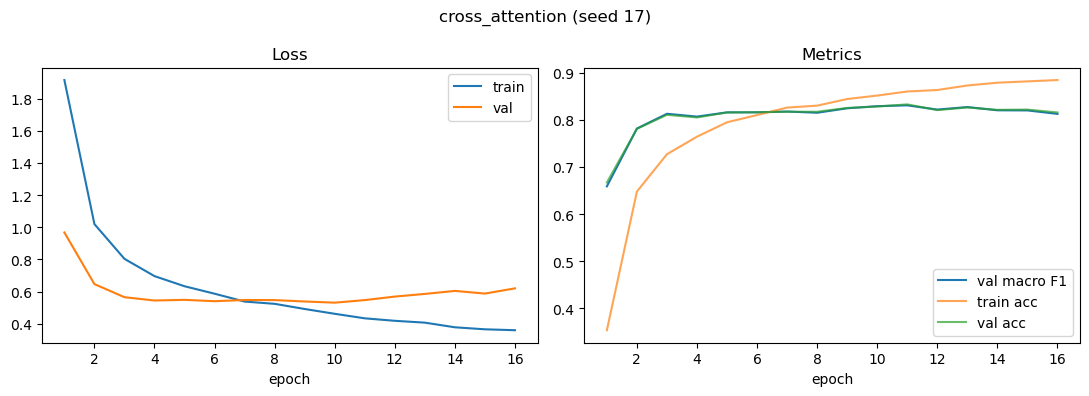

[cross_attention] Experiment 5/10 | split seed = 45
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 1.9156 acc 0.3590 | val loss 0.9170 acc 0.7094 macroF1 0.6965
  Epoch 02 | train loss 1.0207 acc 0.6408 | val loss 0.6332 acc 0.7714 macroF1 0.7656
  Epoch 03 | train loss 0.8090 acc 0.7261 | val loss 0.5704 acc 0.7977 macroF1 0.7945
  Epoch 04 | train loss 0.7018 acc 0.7705 | val loss 0.4931 acc 0.8305 macroF1 0.8314
  Epoch 05 | train loss 0.6406 acc 0.7915 | val loss 0.5011 acc 0.8269 macroF1 0.8264
  Epoch 06 | train loss 0.5852 acc 0.8108 | val loss 0.4792 acc 0.8406 macroF1 0.8398
  Epoch 07 | train loss 0.5541 acc 0.8222 | val loss 0.5148 acc 0.8300 macroF1 0.8282
  Epoch 08 | train loss 0.5129 acc 0.8320 | val loss 0.5054 acc 0.8396 macroF1 0.8393
  Epoch 09 | train loss 0.4842 acc 0.8420 | val loss 0.4957 acc 0.8355 macroF1 0.8356
  Epoch 10 | train loss 0.4561 acc 0.8530 | val loss 0.4888 acc 0.8335 macroF1 0.8340
  Epoch 11 | train loss 0.4403 acc 0.8599

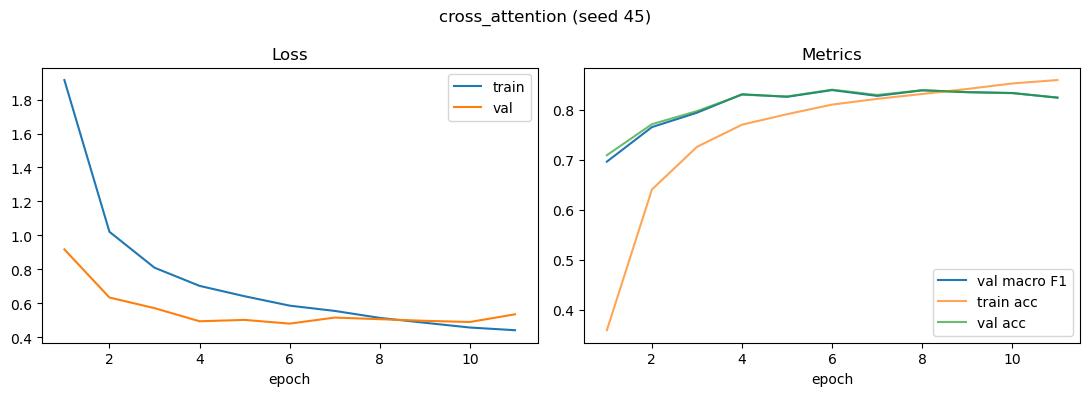

[cross_attention] Experiment 6/10 | split seed = 48
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 1.9041 acc 0.3510 | val loss 0.9244 acc 0.6907 macroF1 0.6766
  Epoch 02 | train loss 1.0178 acc 0.6552 | val loss 0.6973 acc 0.7528 macroF1 0.7466
  Epoch 03 | train loss 0.8050 acc 0.7291 | val loss 0.5730 acc 0.7992 macroF1 0.8001
  Epoch 04 | train loss 0.6883 acc 0.7748 | val loss 0.5783 acc 0.8047 macroF1 0.8019
  Epoch 05 | train loss 0.6364 acc 0.7899 | val loss 0.5248 acc 0.8148 macroF1 0.8144
  Epoch 06 | train loss 0.5823 acc 0.8120 | val loss 0.5234 acc 0.8179 macroF1 0.8175
  Epoch 07 | train loss 0.5355 acc 0.8261 | val loss 0.5089 acc 0.8274 macroF1 0.8271
  Epoch 08 | train loss 0.5079 acc 0.8388 | val loss 0.5650 acc 0.8199 macroF1 0.8192
  Epoch 09 | train loss 0.4780 acc 0.8458 | val loss 0.5372 acc 0.8264 macroF1 0.8264
  Epoch 10 | train loss 0.4517 acc 0.8522 | val loss 0.5604 acc 0.8224 macroF1 0.8217
  Epoch 11 | train loss 0.4345 acc 0.8619

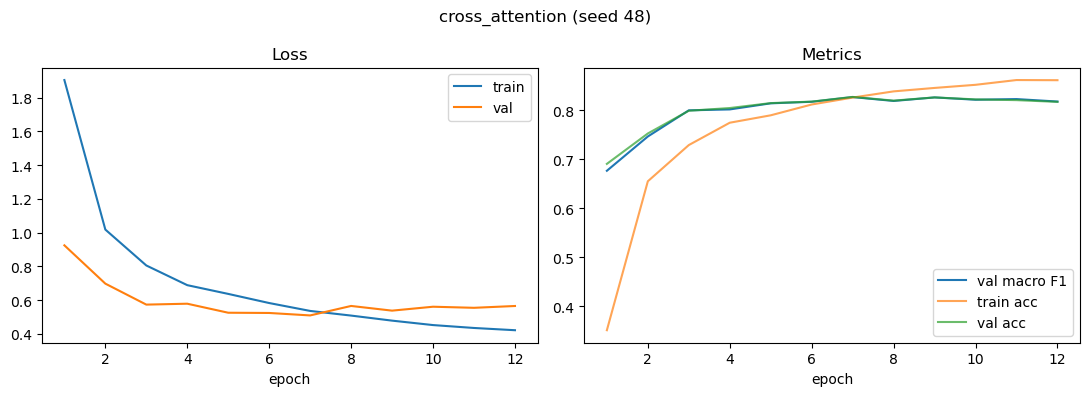

[cross_attention] Experiment 7/10 | split seed = 53
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 1.9233 acc 0.3470 | val loss 0.9132 acc 0.7129 macroF1 0.7039
  Epoch 02 | train loss 1.0476 acc 0.6371 | val loss 0.6657 acc 0.7629 macroF1 0.7623
  Epoch 03 | train loss 0.8110 acc 0.7295 | val loss 0.5803 acc 0.7967 macroF1 0.7964
  Epoch 04 | train loss 0.7095 acc 0.7722 | val loss 0.5815 acc 0.7936 macroF1 0.7924
  Epoch 05 | train loss 0.6357 acc 0.7954 | val loss 0.5637 acc 0.8052 macroF1 0.8070
  Epoch 06 | train loss 0.5792 acc 0.8107 | val loss 0.5549 acc 0.8103 macroF1 0.8113
  Epoch 07 | train loss 0.5412 acc 0.8209 | val loss 0.5771 acc 0.8098 macroF1 0.8083
  Epoch 08 | train loss 0.5171 acc 0.8351 | val loss 0.5318 acc 0.8179 macroF1 0.8180
  Epoch 09 | train loss 0.4806 acc 0.8463 | val loss 0.5456 acc 0.8300 macroF1 0.8292
  Epoch 10 | train loss 0.4632 acc 0.8502 | val loss 0.5314 acc 0.8310 macroF1 0.8302
  Epoch 11 | train loss 0.4364 acc 0.8621

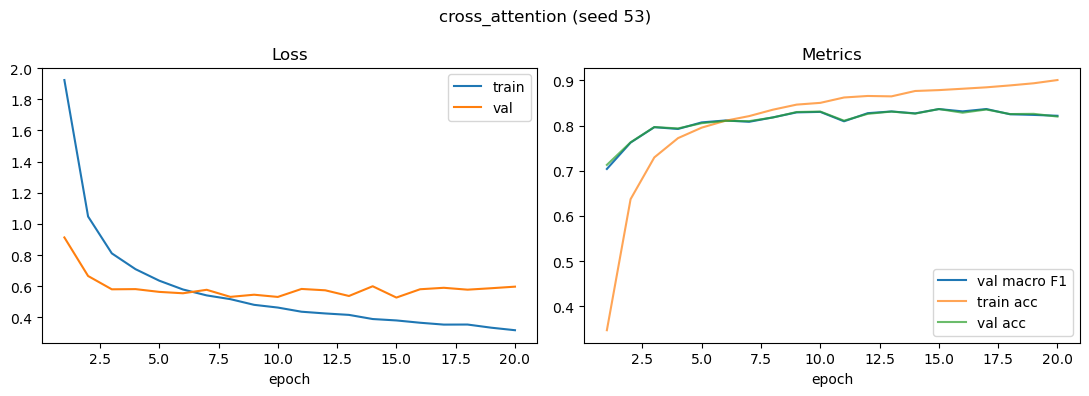

[cross_attention] Experiment 8/10 | split seed = 58
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 1.9065 acc 0.3545 | val loss 0.9175 acc 0.6942 macroF1 0.6775
  Epoch 02 | train loss 1.0181 acc 0.6464 | val loss 0.6495 acc 0.7755 macroF1 0.7731
  Epoch 03 | train loss 0.7958 acc 0.7331 | val loss 0.5931 acc 0.7952 macroF1 0.7963
  Epoch 04 | train loss 0.6898 acc 0.7716 | val loss 0.5695 acc 0.8118 macroF1 0.8118
  Epoch 05 | train loss 0.6349 acc 0.7897 | val loss 0.5911 acc 0.8047 macroF1 0.8055
  Epoch 06 | train loss 0.5633 acc 0.8125 | val loss 0.5748 acc 0.8108 macroF1 0.8097
  Epoch 07 | train loss 0.5480 acc 0.8244 | val loss 0.5468 acc 0.8224 macroF1 0.8243
  Epoch 08 | train loss 0.5075 acc 0.8379 | val loss 0.5762 acc 0.8214 macroF1 0.8204
  Epoch 09 | train loss 0.4701 acc 0.8511 | val loss 0.5528 acc 0.8254 macroF1 0.8260
  Epoch 10 | train loss 0.4423 acc 0.8602 | val loss 0.5779 acc 0.8249 macroF1 0.8254
  Epoch 11 | train loss 0.4285 acc 0.8632

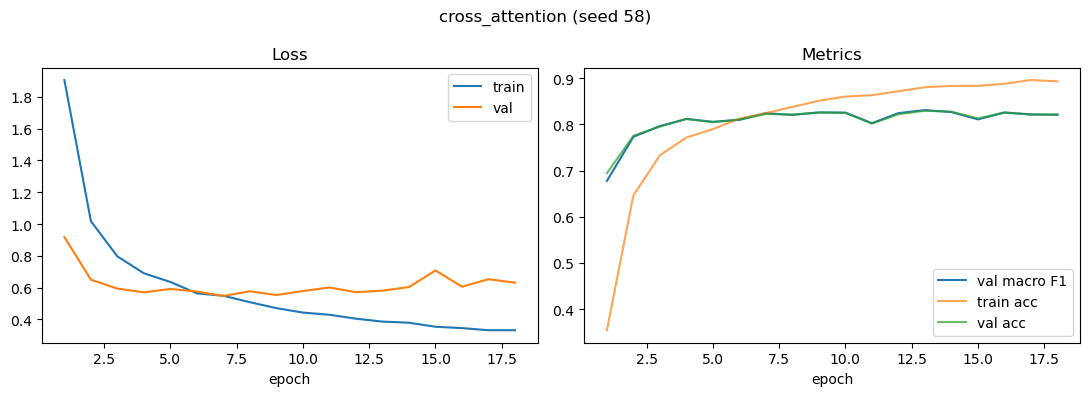

[cross_attention] Experiment 9/10 | split seed = 72
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 1.9314 acc 0.3489 | val loss 0.9391 acc 0.6942 macroF1 0.6824
  Epoch 02 | train loss 1.0389 acc 0.6490 | val loss 0.6489 acc 0.7684 macroF1 0.7679
  Epoch 03 | train loss 0.8073 acc 0.7339 | val loss 0.5794 acc 0.7977 macroF1 0.7983
  Epoch 04 | train loss 0.6883 acc 0.7713 | val loss 0.5507 acc 0.8022 macroF1 0.8034
  Epoch 05 | train loss 0.6370 acc 0.7926 | val loss 0.5450 acc 0.8063 macroF1 0.8060
  Epoch 06 | train loss 0.5778 acc 0.8121 | val loss 0.5201 acc 0.8174 macroF1 0.8192
  Epoch 07 | train loss 0.5282 acc 0.8306 | val loss 0.5293 acc 0.8153 macroF1 0.8127
  Epoch 08 | train loss 0.5093 acc 0.8321 | val loss 0.5528 acc 0.8118 macroF1 0.8090
  Epoch 09 | train loss 0.4877 acc 0.8468 | val loss 0.5363 acc 0.8239 macroF1 0.8248
  Epoch 10 | train loss 0.4642 acc 0.8493 | val loss 0.5092 acc 0.8305 macroF1 0.8317
  Epoch 11 | train loss 0.4446 acc 0.8611

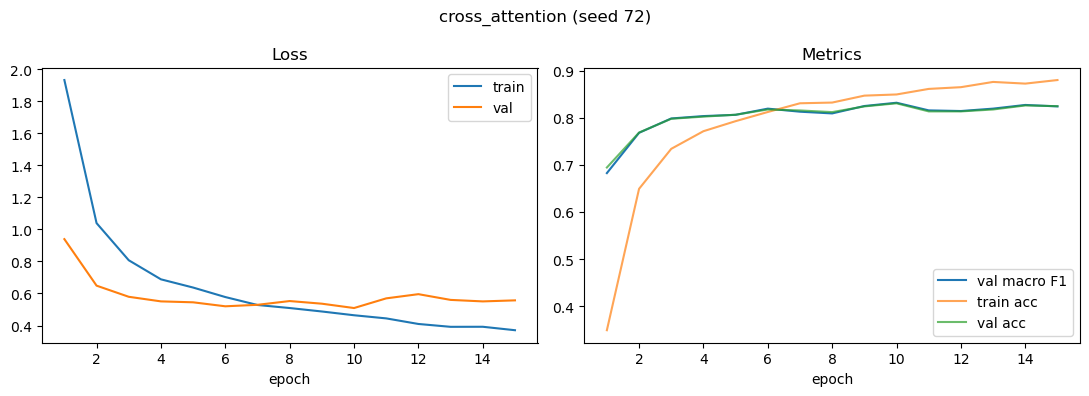

[cross_attention] Experiment 10/10 | split seed = 102
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 1.8950 acc 0.3541 | val loss 0.9028 acc 0.7089 macroF1 0.7069
  Epoch 02 | train loss 1.0106 acc 0.6570 | val loss 0.6623 acc 0.7689 macroF1 0.7653
  Epoch 03 | train loss 0.7843 acc 0.7394 | val loss 0.6146 acc 0.7851 macroF1 0.7815
  Epoch 04 | train loss 0.6882 acc 0.7707 | val loss 0.5605 acc 0.8083 macroF1 0.8080
  Epoch 05 | train loss 0.6140 acc 0.7982 | val loss 0.5236 acc 0.8199 macroF1 0.8210
  Epoch 06 | train loss 0.5678 acc 0.8133 | val loss 0.5598 acc 0.8068 macroF1 0.8038
  Epoch 07 | train loss 0.5226 acc 0.8299 | val loss 0.5333 acc 0.8280 macroF1 0.8275
  Epoch 08 | train loss 0.5054 acc 0.8439 | val loss 0.5374 acc 0.8264 macroF1 0.8254
  Epoch 09 | train loss 0.4782 acc 0.8454 | val loss 0.5711 acc 0.8199 macroF1 0.8198
  Epoch 10 | train loss 0.4467 acc 0.8560 | val loss 0.5868 acc 0.8224 macroF1 0.8222
  Epoch 11 | train loss 0.4285 acc 0.86

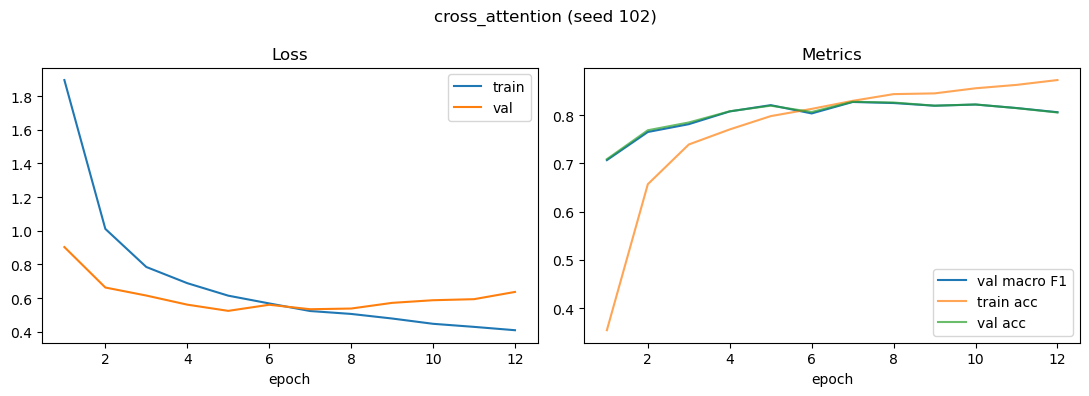

Saved per-seed summary: /home/sandy/Document/FusionStyle/results/multimodal/cross_attention/all_seeds_summary.csv


,seed,accuracy,macro_precision,macro_recall,macro_f1,loss
0,13,0.835015,0.835649,0.837031,0.835141,0.491522
1,14,0.828456,0.831862,0.830859,0.829003,0.537539
2,16,0.837033,0.841370,0.839144,0.838181,0.478332
3,17,0.845610,0.846604,0.849799,0.844473,0.513235
4,45,0.827952,0.828868,0.832139,0.828081,0.499259
5,48,0.848133,0.850364,0.850746,0.848248,0.494319
6,53,0.853179,0.857721,0.854076,0.854265,0.527758
7,58,0.818870,0.825533,0.820276,0.819736,0.629321
8,72,0.836529,0.837915,0.837304,0.836371,0.485741
9,102,0.837538,0.838920,0.837819,0.836670,0.549911


In [22]:
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
rows: List[Dict[str, Any]] = []

for seed_idx, seed_value in enumerate(SEEDS, start=1):
    seed_dir = RESULTS_ROOT / f"seed_{seed_value}"
    done_marker = seed_dir / "test_metrics.json"
    if done_marker.is_file():
        print(f"[{MODEL_KEY}] Seed {seed_value} ({seed_idx}/{len(SEEDS)}): skip (already done)")
        with open(done_marker, encoding="utf-8") as f:
            cached = json.load(f)
        rows.append({"seed": seed_value, **cached})
        continue

    print("=" * 70)
    print(f"[{MODEL_KEY}] Experiment {seed_idx}/{len(SEEDS)} | split seed = {seed_value}")
    print("=" * 70)
    train_df, val_df, test_df = split_by_seed(df_full, seed_value)
    print(f"  Split sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
    train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)
    result = train_cross_attention_seed(
        seed_value, train_loader, val_loader, test_loader, train_df, seed_dir
    )
    rows.append({"seed": seed_value, **{k: float(v) for k, v in result["test_metrics"].items()}})

summary_cross_attention = pd.DataFrame(rows)
summary_cross_attention.to_csv(RESULTS_ROOT / "all_seeds_summary.csv", index=False, encoding="utf-8")
print(f"Saved per-seed summary: {RESULTS_ROOT / 'all_seeds_summary.csv'}")
summary_cross_attention


## 8. Evaluation and aggregation summary

After all seeds finish (section 6), this cell loads saved test metrics and prints overall and per-style summaries.


In [23]:
agg_df, pc_df = aggregate_cross_attention_results()

if len(agg_df):
    print("\n" + "=" * 80)
    print(f"AGGREGATION SUMMARY — {MODEL_KEY} ({len(SEEDS)} seeds)")
    print("=" * 80)
    show_cols = ["model", "metric", "mean", "std", "min", "max", "ci_95_lower", "ci_95_upper", "n"]
    print(agg_df[show_cols].to_string(index=False))

if len(pc_df):
    print("\n" + "=" * 50)
    print(f"PER-CLASS PERFORMANCE SUMMARY — {MODEL_KEY} ({len(SEEDS)} seeds)")
    print("=" * 50)
    print(pc_df[["Style", "F1_Mean", "F1_Std", "F1_CV%"]].to_string(index=False))
    print(f"\nSaved: {RESULTS_ROOT / 'aggregation_summary.csv'}")
    print(f"Saved: {RESULTS_ROOT / 'per_class_metrics_summary.csv'}")
    display(pc_df)
else:
    print("No aggregation results yet. Run section 6 first.")



AGGREGATION SUMMARY — cross_attention (10 seeds)
          model          metric     mean      std      min      max  ci_95_lower  ci_95_upper  n
cross_attention        accuracy 0.836831 0.009734 0.818870 0.853179     0.829491     0.844172 10
cross_attention macro_precision 0.839481 0.009424 0.825533 0.857721     0.832374     0.846587 10
cross_attention    macro_recall 0.838919 0.009767 0.820276 0.854076     0.831555     0.846284 10
cross_attention        macro_f1 0.837017 0.009630 0.819736 0.854265     0.829755     0.844278 10

PER-CLASS PERFORMANCE SUMMARY — cross_attention (10 seeds)
         Style  F1_Mean   F1_Std   F1_CV%
  conservative 0.768021 0.038275 4.983542
        dressy 0.954928 0.008136 0.852013
        ethnic 0.861017 0.023971 2.784041
         fairy 0.933591 0.008978 0.961660
      feminine 0.775007 0.020687 2.669219
           gal 0.852934 0.017357 2.035026
       girlish 0.697234 0.026429 3.790605
kireime-casual 0.717010 0.023678 3.302323
        lolita 0.951607 0.0

,model,Style,F1_Mean,F1_Std,F1_CV%,Precision_Mean,Recall_Mean
0,cross_attention,conservative,0.768021,0.038275,4.983542,0.736656,0.806955
1,cross_attention,dressy,0.954928,0.008136,0.852013,0.954913,0.956092
2,cross_attention,ethnic,0.861017,0.023971,2.784041,0.860679,0.865891
3,cross_attention,fairy,0.933591,0.008978,0.961660,0.921260,0.947718
4,cross_attention,feminine,0.775007,0.020687,2.669219,0.801406,0.756198
5,cross_attention,gal,0.852934,0.017357,2.035026,0.856378,0.851049
6,cross_attention,girlish,0.697234,0.026429,3.790605,0.739810,0.662651
7,cross_attention,kireime-casual,0.717010,0.023678,3.302323,0.737173,0.706329
8,cross_attention,lolita,0.951607,0.011935,1.254191,0.962634,0.941789
9,cross_attention,mode,0.820945,0.027663,3.369639,0.835674,0.807547
